# Customer churn: exploratory data analysis

Cleaned version of the EDA in [`01_original_colab_notebook.ipynb`](01_original_colab_notebook.ipynb).
Same questions and findings as the original, but data loading and styling come from `src/`,
it runs outside Colab, and every figure is saved to `reports/figures/` for the README.

Modelling is not done here. It lives in `src/` (`python -m src.train`), and the results are in `reports/`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import load_config, resolve_path
from src.data import load_raw
from src.plot_style import CHURN_COLORS, HIGHLIGHT, INK_SECONDARY, MUTED, apply_style

apply_style()
cfg = load_config()
FIGURES = resolve_path(cfg["paths"]["figures_dir"])
FIGURES.mkdir(parents=True, exist_ok=True)

df = load_raw(resolve_path(cfg["paths"]["raw_train"]))
print(f"{len(df):,} customers, {df.shape[1] - 2} features (+ id and the Churn target)")
df["Churned"] = (df["Churn"] == "Yes").astype(int)

594,194 customers, 19 features (+ id and the Churn target)


## 1. Data overview

In [2]:
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churned
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No,0
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No,0
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No,0
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes,1
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes,1


In [3]:
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique values": df.nunique(),
})
overview

,dtype,missing,unique values
id,int64,0,594194
gender,category,0,2
SeniorCitizen,int64,0,2
Partner,category,0,2
Dependents,category,0,2
tenure,int64,0,72
PhoneService,category,0,2
MultipleLines,category,0,3
InternetService,category,0,3
OnlineSecurity,category,0,3


No missing values and no duplicated rows. `TotalCharges` is already numeric in this Kaggle version
(in the original IBM Telco data it contains blank strings, so the pipeline still coerces it).

In [4]:
print("Duplicated rows (ignoring id):", df.drop(columns="id").duplicated().sum())
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe().round(2)

Duplicated rows (ignoring id): 0


,tenure,MonthlyCharges,TotalCharges
count,594194.00,594194.00,594194.00
mean,36.58,65.87,2494.38
std,25.06,31.07,2353.92
min,1.00,18.25,18.80
25%,12.00,29.90,639.65
50%,35.00,74.10,1433.65
75%,62.00,90.80,4263.80
max,72.00,118.75,8684.80


## 2. Target distribution

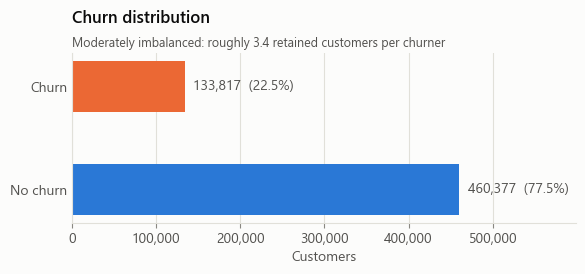

In [5]:
counts = df["Churn"].value_counts().reindex(["No", "Yes"])
shares = counts / counts.sum()

fig, ax = plt.subplots(figsize=(6.5, 2.2))
ax.barh(["No churn", "Churn"], counts.values, height=0.5, color=[CHURN_COLORS["No"], CHURN_COLORS["Yes"]])
for i, (n, s) in enumerate(zip(counts.values, shares.values)):
    ax.annotate(f"{n:,}  ({s:.1%})", (n, i), xytext=(6, 0), textcoords="offset points",
                va="center", color=INK_SECONDARY)
ax.set_xlim(0, counts.max() * 1.3)
ax.xaxis.set_major_formatter("{x:,.0f}")
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.set_xlabel("Customers")
ax.set_title("Churn distribution", pad=22)
ax.text(0, 1.04, "Moderately imbalanced: roughly 3.4 retained customers per churner",
        transform=ax.transAxes, color=INK_SECONDARY, fontsize=9)
fig.savefig(FIGURES / "eda_churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

22.5% of customers churn. A model that always predicts "no churn" is already 77.5% accurate, so
accuracy alone is a misleading metric here. Models are compared on ROC-AUC, precision, recall and F1 instead.

## 3. Churn rate by category

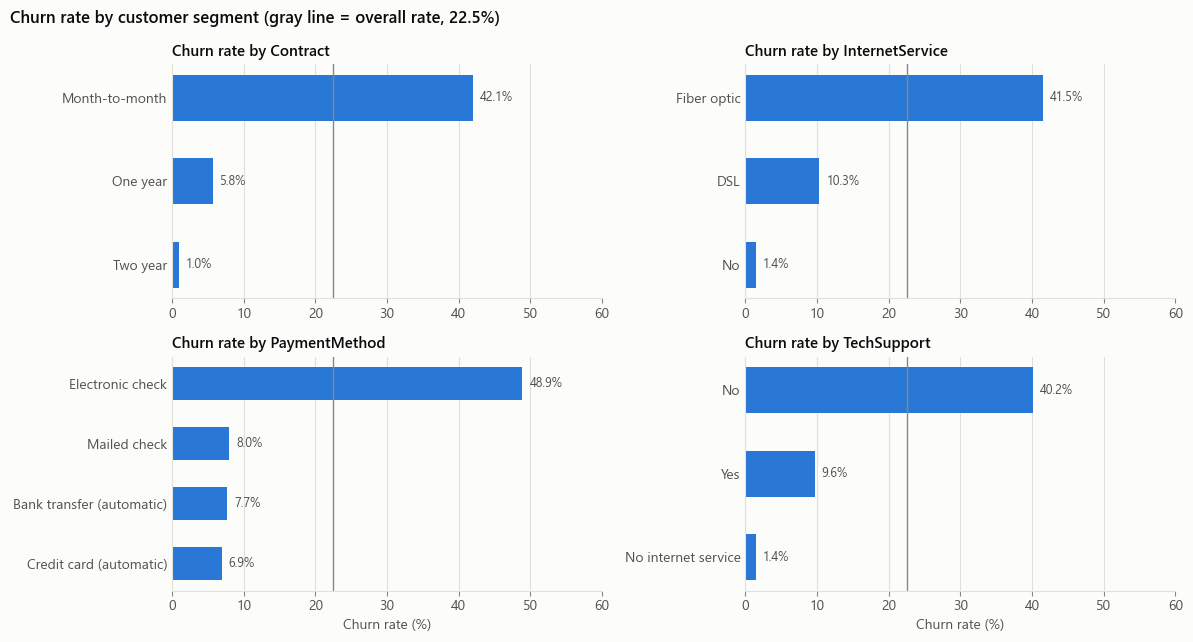

In [6]:
def churn_rate_by(col):
    return df.groupby(col, observed=True)["Churned"].mean().sort_values() * 100

overall = df["Churned"].mean() * 100
features = ["Contract", "InternetService", "PaymentMethod", "TechSupport"]

fig, axes = plt.subplots(2, 2, figsize=(12, 6.5))
for ax, col in zip(axes.flat, features):
    rates = churn_rate_by(col)
    ax.barh(rates.index.astype(str), rates.values, height=0.55, color=HIGHLIGHT)
    for i, v in enumerate(rates.values):
        ax.annotate(f"{v:.1f}%", (v, i), xytext=(5, 0), textcoords="offset points", va="center",
                    color=INK_SECONDARY, fontsize=9)
    ax.axvline(overall, color=MUTED, linewidth=1)
    ax.set_xlim(0, 60)
    ax.grid(axis="y", visible=False)
    ax.tick_params(axis="y", length=0)
    ax.set_title(f"Churn rate by {col}", fontsize=11)
axes[1, 0].set_xlabel("Churn rate (%)")
axes[1, 1].set_xlabel("Churn rate (%)")
fig.suptitle(f"Churn rate by customer segment (gray line = overall rate, {overall:.1f}%)",
             x=0.01, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout()
fig.savefig(FIGURES / "eda_churn_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

Every categorical column, ranked by the spread in churn rate between its best and worst level:

In [7]:
categorical = [c for c in df.select_dtypes("category").columns if c != "Churn"]
rows = []
for col in categorical:
    rates = churn_rate_by(col)
    rows.append({"feature": col, "lowest level": rates.index[0], "lowest %": rates.iloc[0],
                 "highest level": rates.index[-1], "highest %": rates.iloc[-1]})
spread = pd.DataFrame(rows).set_index("feature")
spread["spread (pp)"] = spread["highest %"] - spread["lowest %"]
spread.sort_values("spread (pp)", ascending=False).round(1)

,lowest level,lowest %,highest level,highest %,spread (pp)
feature,,,,,
PaymentMethod,Credit card (automatic),6.9,Electronic check,48.9,42.0
Contract,Two year,1.0,Month-to-month,42.1,41.1
InternetService,No,1.4,Fiber optic,41.5,40.1
OnlineSecurity,No internet service,1.4,No,40.6,39.2
TechSupport,No internet service,1.4,No,40.2,38.7
OnlineBackup,No internet service,1.4,No,39.1,37.7
DeviceProtection,No internet service,1.4,No,38.1,36.6
StreamingMovies,No internet service,1.4,No,29.9,28.5
StreamingTV,No internet service,1.4,No,29.7,28.3


## 4. Numeric features by churn

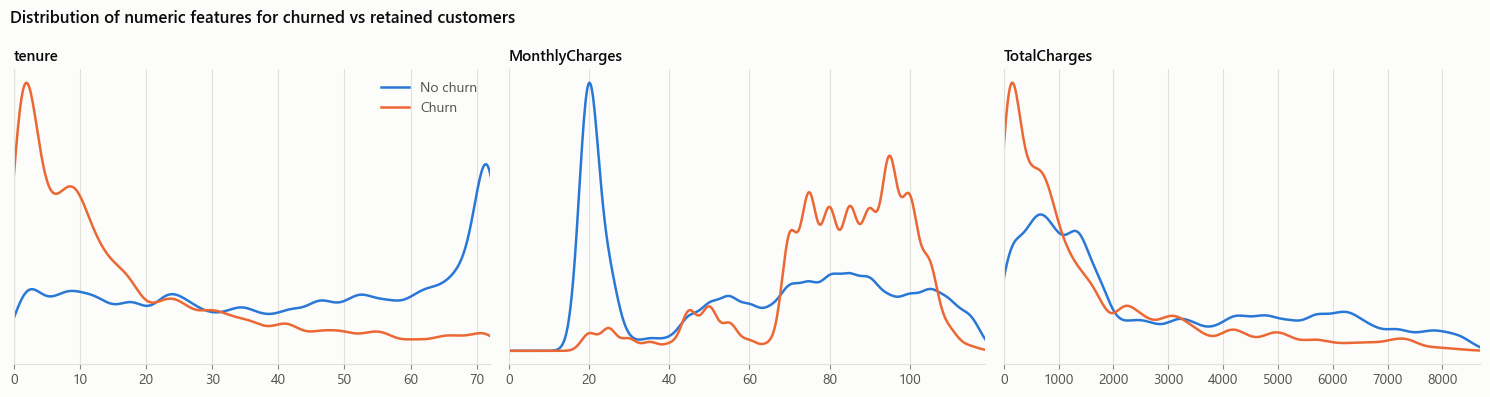

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    for label, name in [("No", "No churn"), ("Yes", "Churn")]:
        values = df.loc[df["Churn"] == label, col]
        values.plot.kde(ax=ax, color=CHURN_COLORS[label], linewidth=1.8, label=name)
    ax.set_xlim(0, df[col].max())
    ax.set_ylabel("")
    ax.set_yticks([])
    ax.set_title(col, fontsize=11)
axes[0].legend()
fig.suptitle("Distribution of numeric features for churned vs retained customers",
             x=0.01, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout()
fig.savefig(FIGURES / "eda_numeric_by_churn.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
df.groupby("Churn", observed=True)[["MonthlyCharges", "tenure"]].mean().round(2)

,MonthlyCharges,tenure
Churn,,
No,61.29,42.23
Yes,81.60,17.13


Churned customers have been with the company for **17 months on average vs 42 months** for retained
customers, and pay about **$20 more per month**. The churn rate by tenure shows where the risk sits:

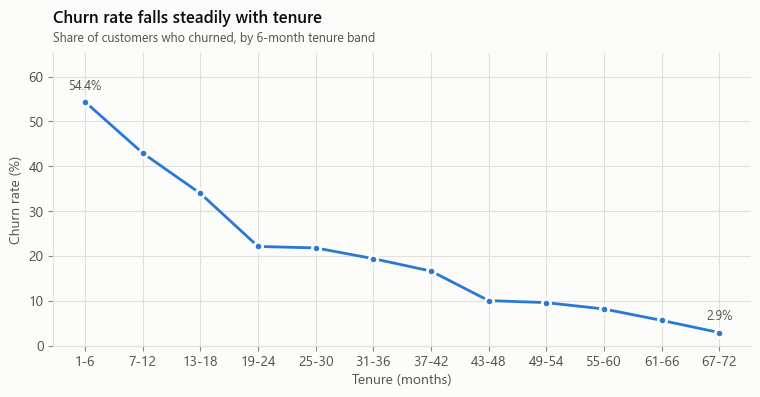

Churn in the first year: 49.4% | after 4 years: 5.3%


In [10]:
bins = list(range(0, 73, 6))
by_tenure = df.groupby(pd.cut(df["tenure"], bins=bins), observed=True)["Churned"].mean() * 100
labels = [f"{b.left + 1}-{b.right}" for b in by_tenure.index]

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(labels, by_tenure.values, color=HIGHLIGHT, linewidth=2, marker="o", markersize=6,
        markeredgecolor="#fcfcfb", markeredgewidth=2)
for i in (0, len(labels) - 1):
    ax.annotate(f"{by_tenure.values[i]:.1f}%", (i, by_tenure.values[i]), xytext=(0, 9),
                textcoords="offset points", ha="center", color=INK_SECONDARY, fontsize=9)
ax.set_ylim(0, by_tenure.max() * 1.2)
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn rate falls steadily with tenure", pad=22)
ax.text(0, 1.04, "Share of customers who churned, by 6-month tenure band",
        transform=ax.transAxes, color=INK_SECONDARY, fontsize=9)
fig.savefig(FIGURES / "eda_churn_by_tenure.png", dpi=150, bbox_inches="tight")
plt.show()

first_year = df.loc[df["tenure"] <= 12, "Churned"].mean()
after_4_years = df.loc[df["tenure"] > 48, "Churned"].mean()
print(f"Churn in the first year: {first_year:.1%} | after 4 years: {after_4_years:.1%}")

## 5. Key insights

In [11]:
contract = churn_rate_by("Contract")
payment = churn_rate_by("PaymentMethod")
echeck = payment["Electronic check"]
other_payment = df.loc[df["PaymentMethod"] != "Electronic check", "Churned"].mean() * 100
means = df.groupby("Churn", observed=True)[["MonthlyCharges", "tenure"]].mean()

print(f"Month-to-month churn {contract['Month-to-month']:.1f}% vs two-year {contract['Two year']:.1f}% "
      f"-> {contract['Month-to-month'] / contract['Two year']:.0f}x")
print(f"Electronic check churn {echeck:.1f}% vs other methods {other_payment:.1f}% -> {echeck / other_payment:.1f}x")
print(f"No tech support {churn_rate_by('TechSupport')['No']:.1f}% | "
      f"fiber optic {churn_rate_by('InternetService')['Fiber optic']:.1f}%")
print(f"Churners pay ${means.loc['Yes', 'MonthlyCharges'] - means.loc['No', 'MonthlyCharges']:.2f} more per month")

Month-to-month churn 42.1% vs two-year 1.0% -> 42x
Electronic check churn 48.9% vs other methods 7.5% -> 6.5x
No tech support 40.2% | fiber optic 41.5%
Churners pay $20.30 more per month


- **Contract type is the strongest segment signal.** Month-to-month customers churn at 42%, about 42x
  the rate of two-year customers (1%).
- **Electronic check payers churn at 49%**, about 6.5x the rate of customers on any other payment method.
- **No tech support (40%) and fiber optic internet (41.5%)** are the other high-risk segments.
- **Risk is concentrated early in the relationship.** About half of customers in their first year churn,
  vs about 5% after four years. Churners' average tenure is 17 months vs 42 for retained customers.
- **Churners pay about $20 more per month** on average ($81.60 vs $61.29).

These findings match the model's permutation importance (`reports/figures/feature_importance.png`), where
tenure, contract and charges dominate.